In [17]:
from transformers import RobertaForMaskedLM
import matplotlib.pyplot as plt
import numpy as np

In [18]:
def flatten_model(m_init):
    params_init = []
    flat_init = []
    for l in list(range(12)):
        layer = []    
        for name, param in m_init.named_parameters():
            if name[8:15] == "encoder" and name[-6:] == "weight" and name[-16:-7] != "LayerNorm"  and (name[22:24] == str(l)+"." or name[22:25] == str(l)+"."):
                #print(name)
                # print(param)
                param_np = param.detach().numpy()
                if param_np.ndim > 1:
                    layer.extend(param_np)
                else:
                    layer.append(param_np)
        params_init.append(layer)
    for layer in params_init:
        flattened = [i for p in layer for i in p]
        flat_init.append(flattened)
    return flat_init

In [22]:
def weight_hist(flattened_params, model_name, log = False, filter_high = False):
    cmap = plt.get_cmap('tab20')
    for idx, layer in enumerate(flattened_params):
        #sns.kdeplot(layer, label = str(idx))
        # if log == True:
        #     layer = np.log1p(layer)
        if filter_high == True:
            layer = [i for i in layer if abs(i) < 0.6]
        counts, edges = np.histogram(layer, bins = 100)
        if log == True:
            counts = np.log10([i+1 for i in counts])
        centers = (edges[:-1]+edges[1:])/2
        plt.plot(centers, counts, label = str(idx), color = cmap(idx))
        #plt.bar(hist[1][:-1], height=hist[0], width=np.diff(hist[1]), align = "edge",alpha = 0.5, label = str(idx))
    plt.title(model_name)
    if log == True:
        plt.ylabel("Log10 Counts")
    else:
        plt.ylabel("Counts")
    plt.xlabel("Weight Value")
    plt.legend(title = "Layer")
    plt.show()

In [4]:
m1 = RobertaForMaskedLM.from_pretrained("/media/easystore/initialization_all_epochs/roberta_10M/epoch_20")

In [6]:
m1_2 = RobertaForMaskedLM.from_pretrained("/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_10M/hf_20")

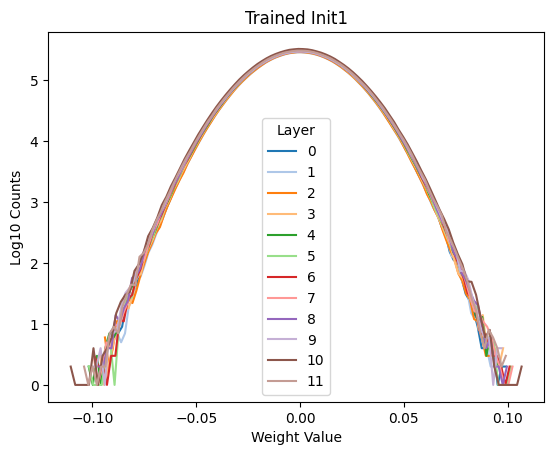

In [8]:
flat1 = flatten_model(m1)
weight_hist(flat1, "Trained Init1", log = True)

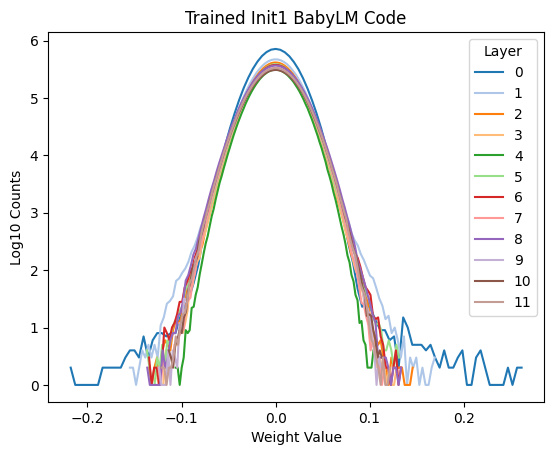

In [9]:
flat1_2 = flatten_model(m1_2)
weight_hist(flat1_2, "Trained Init1 BabyLM Code", log = True)

In [ ]:
m1_init = RobertaForMaskedLM.from_pretrained("/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_init")

for name, param in m1.named_parameters():
    if "encoder" in name and "weight" in name and "LayerNorm" not in name:
        print(name)
        p = param.data
        p2 = m1_init.state_dict()[name].data
        print(p == p2)

In [ ]:
p

In [ ]:
p2

In [7]:
m2 = RobertaForMaskedLM.from_pretrained("/media/easystore/initialization_all_epochs/roberta_10M_init2/epoch_20")

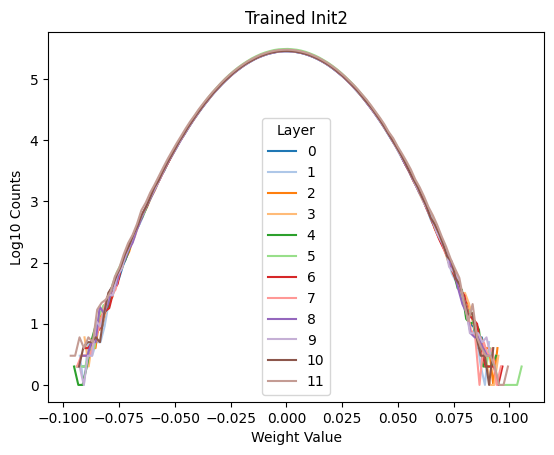

In [10]:
flat2 = flatten_model(m2)
weight_hist(flat2, "Trained Init2", log = True)

In [ ]:
m3 = RobertaForMaskedLM.from_pretrained("/media/easystore/initialization_all_epochs/roberta_10M_init3/epoch_20")

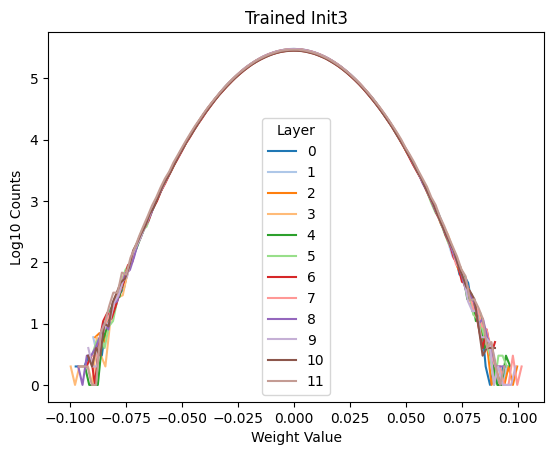

In [13]:
flat3 = flatten_model(m3)
weight_hist(flat3, "Trained Init3", log = True)

In [1]:
m100 = RobertaForMaskedLM.from_pretrained("/media/anna/easystore/initialization_all_epochs/roberta_100M/epoch_20_0")

NameError: name 'RobertaForMaskedLM' is not defined

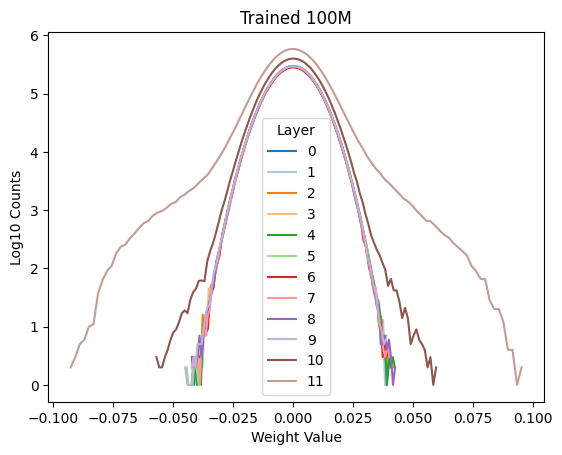

In [6]:
flat100 = flatten_model(m100)
weight_hist(flat100, "Trained 100M", log = True)

In [9]:
m100_2 = RobertaForMaskedLM.from_pretrained("/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_100M/hf_20")

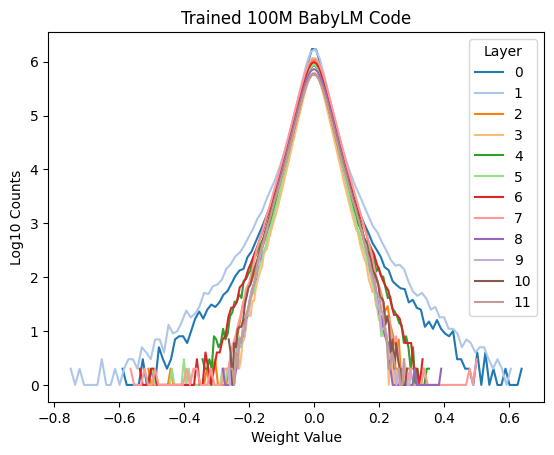

In [10]:
flat100_2 = flatten_model(m100_2)
weight_hist(flat100_2, "Trained 100M BabyLM Code", log = True)

In [11]:
m2B = RobertaForMaskedLM.from_pretrained("/media/easystore/initialization_all_epochs/roberta_2B/final")

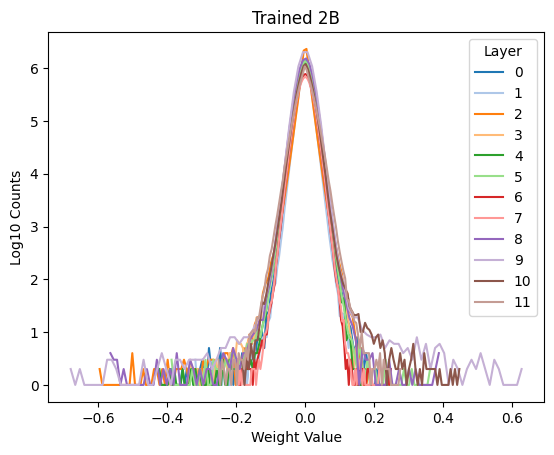

In [12]:
flat2B = flatten_model(m2B)
weight_hist(flat2B, "Trained 2B", log = True)

In [13]:
base = RobertaForMaskedLM.from_pretrained("roberta-base")

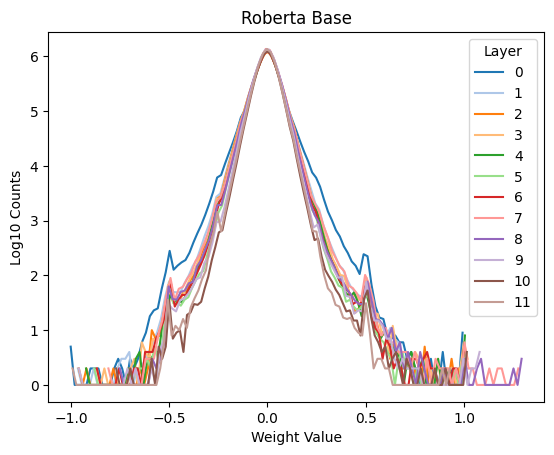

In [15]:
flatbase = flatten_model(base)
weight_hist(flatbase, "Roberta Base", log = True)

In [16]:
raw = RobertaForMaskedLM.from_pretrained("/media/easystore/initialization_all_epochs/mask_10M_raw/epoch_20")

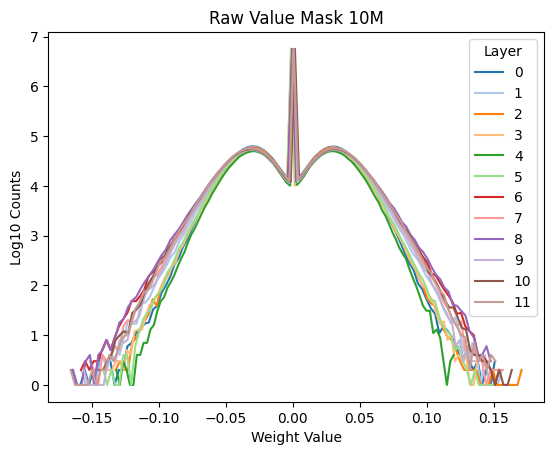

In [17]:
flatraw = flatten_model(raw)
weight_hist(flatraw, "Raw Value Mask 10M", log = True)

In [18]:
init1 = RobertaForMaskedLM.from_pretrained("/media/easystore/initialization_all_epochs/roberta_10M_init1/epoch_20")

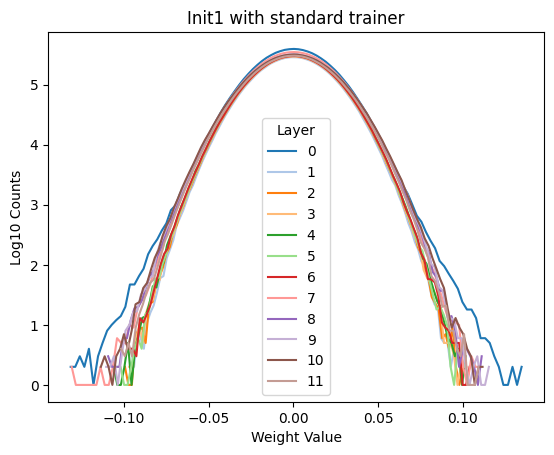

In [19]:
flatinit1 = flatten_model(init1)
weight_hist(flatinit1, "Init1 with standard trainer", log = True)

In [20]:
init4 = RobertaForMaskedLM.from_pretrained("/media/easystore/initialization_all_epochs/roberta_10M_init4/epoch_20")

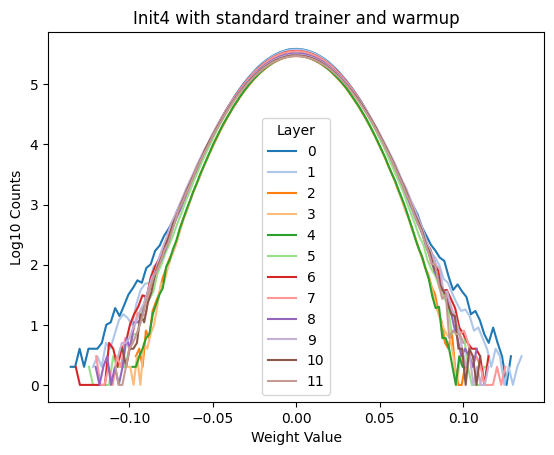

In [26]:
flatinit4 = flatten_model(init4)
weight_hist(flatinit4, "Init4 with standard trainer and warmup", log = True)

In [23]:
init4c = RobertaForMaskedLM.from_pretrained("/media/easystore/initialization_all_epochs/roberta_10M_init4_cust/epoch_20")

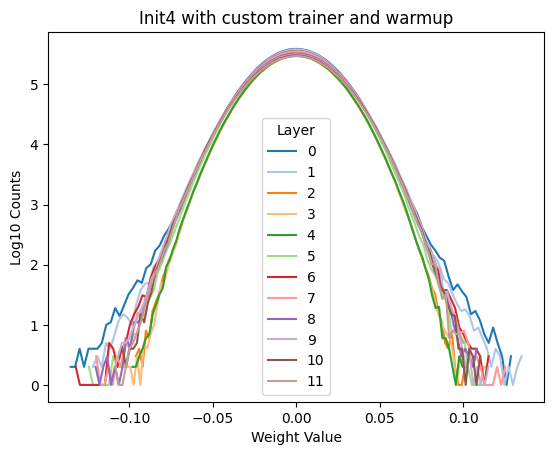

In [24]:
flatinit4c = flatten_model(init4c)
weight_hist(flatinit4c, "Init4 with custom trainer and warmup", log = True)

In [ ]:
for name, param in init4.named_parameters():
    if "weight" in name and "encoder" in name and "LayerNorm" not in name:
        p = param.data
        p1 = init4c.state_dict()[name].data
        print(p == p1)
        

In [28]:
init2nb = RobertaForMaskedLM.from_pretrained("/media/easystore/initialization_all_epochs/roberta_10M_init2_nobaby/epoch_20_")

In [ ]:
flatinit2nb = flatten_model(init2nb)
weight_hist(flatinit2nb, "Init2 with standard trainer and wiki data loader", log = True)

In [4]:
m100 = RobertaForMaskedLM.from_pretrained("/media/easystore/initialization_all_epochs/roberta_100M/final")

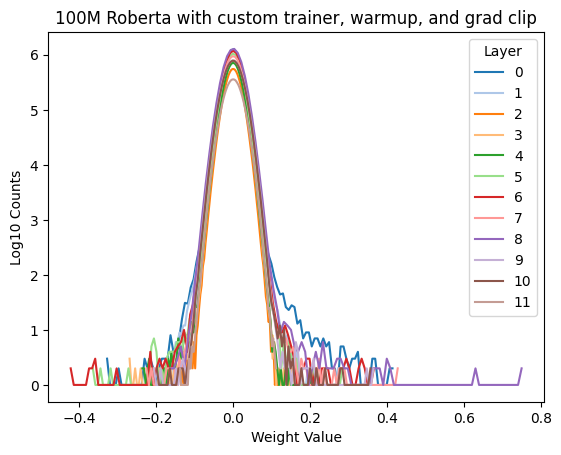

In [8]:
flatm100 = flatten_model(m100)
weight_hist(flatm100, "100M Roberta with custom trainer, warmup, and grad clip", log = True)

In [34]:
m10mg = RobertaForMaskedLM.from_pretrained("/media/easystore/initialization_all_epochs/roberta_10M_init1_maxgrad/epoch_20")

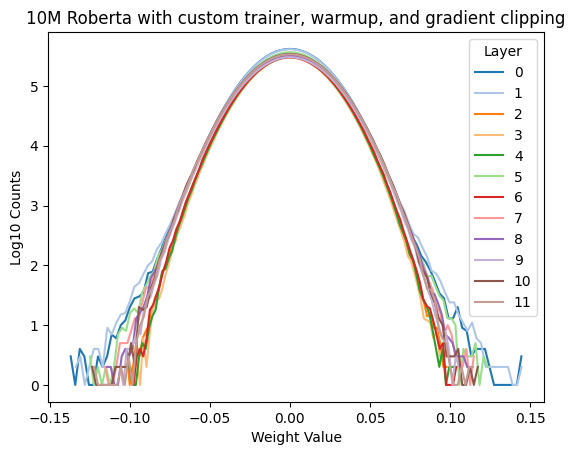

In [35]:
flatm10mg = flatten_model(m10mg)
weight_hist(flatm10mg, "10M Roberta with custom trainer, warmup, and gradient clipping", log = True)

In [25]:
m10clr = RobertaForMaskedLM.from_pretrained("/media/easystore/initialization_all_epochs/roberta_10M_clr/final")

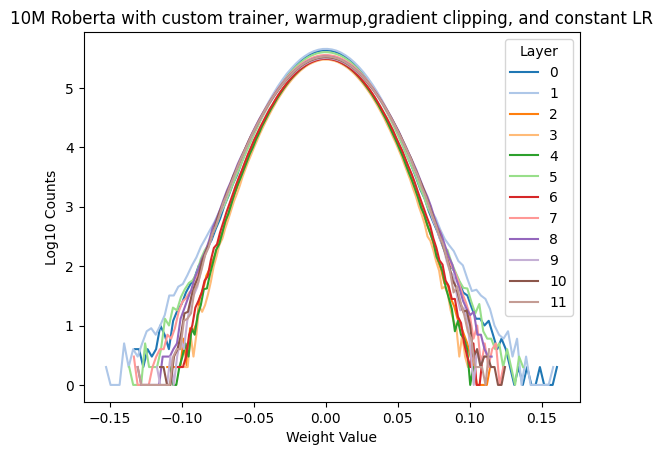

In [26]:
flatm10clr = flatten_model(m10clr)
weight_hist(flatm10clr, "10M Roberta with custom trainer, warmup,gradient clipping, and constant LR", log = True)

In [20]:
m100clr = RobertaForMaskedLM.from_pretrained("/media/easystore/initialization_all_epochs/roberta_100M_clr/final")

In [ ]:
flatm100clr = flatten_model(m100clr)

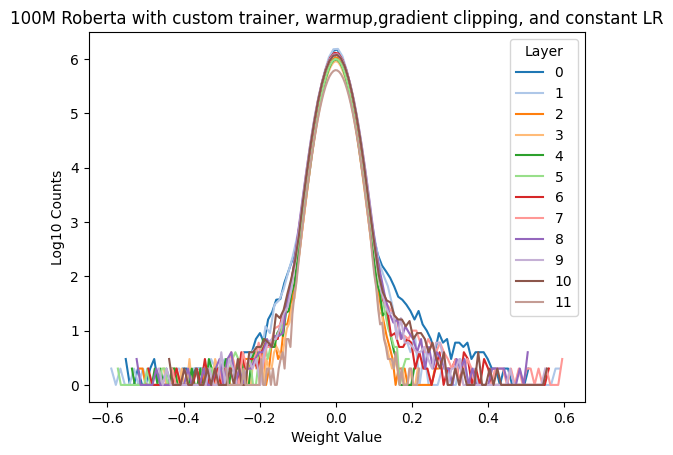

In [23]:
weight_hist(flatm100clr, "100M Roberta with custom trainer, warmup,gradient clipping, and constant LR", log = True, filter_high = True)

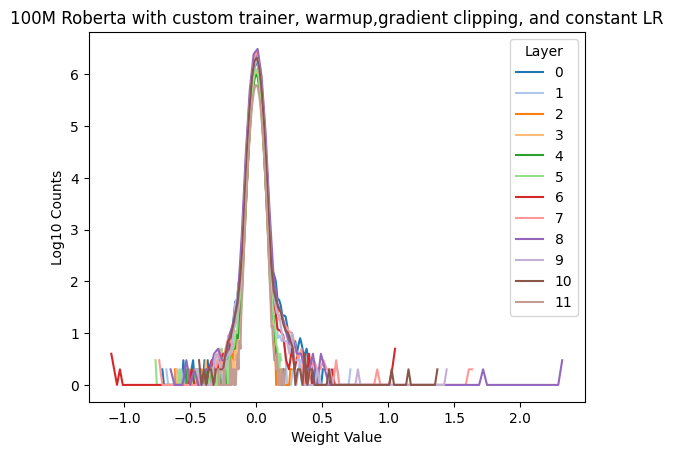

In [24]:
weight_hist(flatm100clr, "100M Roberta with custom trainer, warmup,gradient clipping, and constant LR", log = True)

In [27]:
baby=RobertaForMaskedLM.from_pretrained("/media/anna/Samsung_T5/Initialization/HPC_store/models/babylm_store_sync/babyLM_10M/roberta_10M/hf_20")

In [28]:
flatbaby = flatten_model(baby)

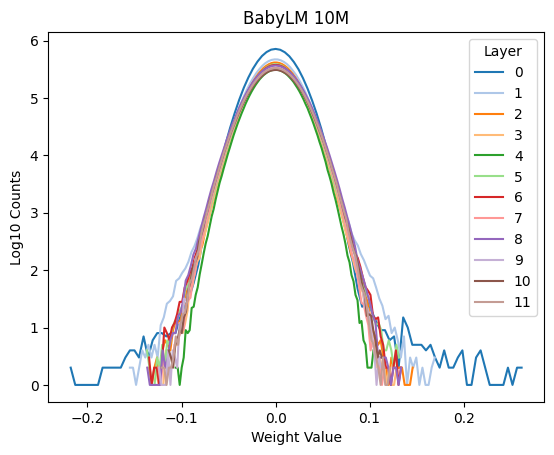

In [29]:
weight_hist(flatbaby, "BabyLM 10M", log = True)